# Exp 2: Implement Gradient Descent Algorithm to minimize given objective function.

Gradient Descent is a method to adjust model parameters step-by-step in order to minimize error and improve predictions.

**What does Gradient Descent do in ML?**

In Machine Learning, Gradient Descent is used to minimize the cost (loss) function, which measures how far predictions are from actual values.

- **Linear Regression** → minimizes Mean Squared Error (MSE).
- **Logistic Regression** → minimizes Log Loss (cross-entropy).

## **Load Data**

In [5]:
import pandas as pd

df = pd.read_csv("customer.csv")
print(df.shape)
df.head()


(18, 6)


,Age,Income,Gender_Male,City_Delhi,City_Mumbai,Purchased
0,-2.078147,-3.870288,1.253566,1.414214,-0.797724,1
1,0.571681,-0.692186,-0.797724,1.414214,-0.797724,1
2,0.479554,0.395851,1.253566,-0.707107,1.253566,1
3,1.637140,0.788091,1.253566,1.414214,-0.797724,1
4,-0.770161,0.131660,-0.797724,-0.707107,-0.797724,1


### **Pick two variables for a 2-parameter convex objective**

In [6]:
# choose one feature to predict another
x_col = "Age"
y_col = "Income"

assert x_col in df.columns and y_col in df.columns, "Check your column names."

# prepare vectors
x = df[x_col].to_numpy().reshape(-1,1)
y = df[y_col].to_numpy().reshape(-1,1)
n = x.shape[0]

# We want to predict Income based on Age
# Mathematical model: Income = w₀ + w₁ × Age
# Where w₀ = intercept, w₁ = slope


In [21]:
from sklearn.model_selection import train_test_split
X = df[['Age']]
y = df[['Income']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X_train) 
X_scaled = np.c_[np.ones(X_scaled.shape[0]), X_scaled] 

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def objective_function(theta, X=X_scaled, y=y_train.values):
    predictions = X.dot(theta)
    return (1/(2*len(y))) * np.sum((predictions - y)**2)

def gradient(theta, X=X_scaled, y=y_train.values):
    predictions = X.dot(theta)
    return (1/len(y)) * X.T.dot(predictions - y)

def gradient_descent(initial_theta, learning_rate, num_iterations):
    theta = initial_theta.copy()
    history = [theta.copy()]
    print(f"{'Iteration':<10}{'Theta[0]':<12}{'Gradient[0]':<15}{'Objective Function'}")
    print("-" * 60)
    for i in range(num_iterations):
        grad = gradient(theta)
        obj_value = objective_function(theta)
        print(f"{i+1:<10}{theta[0]:<12.4f}{grad[0]:<15.4f}{obj_value:<20.4f}")
        theta = theta - learning_rate * grad
        history.append(theta.copy())
    return theta, history

initial_theta = np.zeros(X_scaled.shape[1])
learning_rate = 0.1
num_iterations = 10

optimal_theta, history = gradient_descent(initial_theta, learning_rate, num_iterations)
print(f"\nOptimal theta: {optimal_theta}")
print(f"Value of objective function at optimal theta: {objective_function(optimal_theta):.4f}")

theta_values = np.linspace(-2, 2, 100)
obj_values = [objective_function(np.array([t, 0])) for t in theta_values]
plt.figure(figsize=(10, 6))
plt.plot(theta_values, obj_values, label='Objective Function')
history_theta0 = [h[0] for h in history]
history_obj = [objective_function(h) for h in history]
plt.scatter(history_theta0, history_obj, color='red', label='Gradient Descent Path')
plt.xlabel('Theta[0]')
plt.ylabel('f(theta)')
plt.title('Gradient Descent Optimization on Income vs Age')
plt.legend()
plt.show()


Iteration Theta[0]    Gradient[0]    Objective Function
------------------------------------------------------------


TypeError: unsupported format string passed to numpy.ndarray.__format__

### Step 1: Define the Objective Function
- Write a convex function that returns f(x1,x2)


J(Q0, Q1) = 1/2m Σ (h(xi) - yi)^2 ==> Convex function(Linear Regression Cost Function)

h(xi) = Q0 + Q1*xi 

For MSE ==> MSE = (1/n) * Σ (y_pred - y_true)^2 ==> (i.e 1/n(y_hat - y)^2)

In [7]:
import numpy as np
def mse_cost(w):
    # w = [w₀, w₁] - our parameters to optimize
    # y_hat = predicted values = w₀ + w₁ × x
    # MSE = (1/n) × Σ(predicted - actual)²
    # This measures how far our predictions are from reality
    """w = [w0, w1] column vector (2x1)"""
    w0, w1 = w[0,0], w[1,0]
    y_hat = w0 + w1 * x
    return (1/n) * np.sum((y_hat - y)**2)


**Compute the Gradient
∇
𝑓
(
𝑤
0
,
𝑤
1
)**


In [4]:
def mse_grad(w):
    # Gradient tells us which direction to move w₀ and w₁
    # ∂MSE/∂w₀ = (2/n) × Σ(error)
    # ∂MSE/∂w₁ = (2/n) × Σ(x × error)
    # These formulas come from calculus
    w0, w1 = w[0,0], w[1,0]
    y_hat = w0 + w1 * x
    err = (y_hat - y)
    d_w0 = (2/n) * np.sum(err)
    d_w1 = (2/n) * np.sum(x * err)
    return np.array([[d_w0],[d_w1]])


**Implement Gradient Descent**

In [8]:
# Step 3: Implement Gradient Descent Algorithm
def gradient_descent(starting_point, learning_rate, iterations):
    x = np.array(starting_point, dtype='float64')
    path = [x.copy()]
    for _ in range(iterations):
        grad = mse_grad(x)
        x -= learning_rate * grad
        path.append(x.copy())
    return x, path

In [10]:
# Initialize parameters
alpha = 0.1
n_iterations = 50
initial_x = [4.0, 3.0]

# Run gradient descent
initial_x_col = np.array(initial_x).reshape(-1, 1)
final_x, path = gradient_descent(initial_x_col, alpha, n_iterations)

In [12]:
# Step 4: Print final results
print("Final values:")
print(f"x1 = {final_x[0].item():.4f}, x2 = {final_x[1].item():.4f}")
print(f"f(x1, x2) = {mse_cost(final_x):.4f}")

Final values:
x1 = 0.0001, x2 = 0.6563
f(x1, x2) = 0.5693


In [13]:
# Step 5: Visualize the Optimization Path
path = np.array(path)

In [14]:
import matplotlib.pyplot as plt

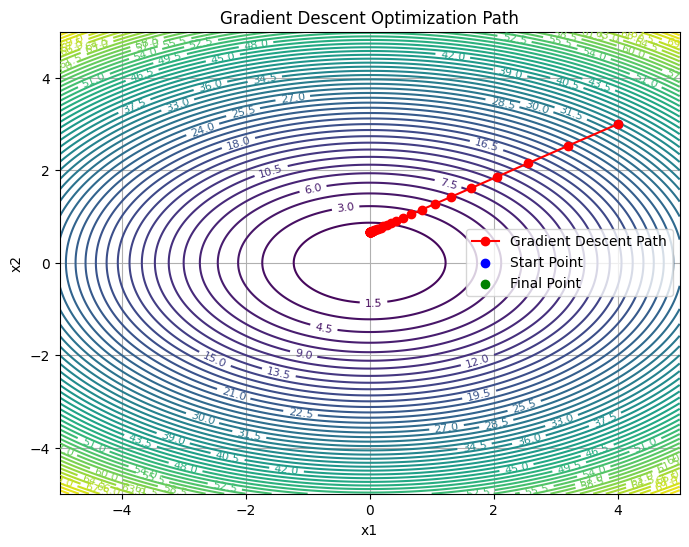

In [18]:
# Step 5: Visualize the Optimization Path
path = np.array(path)

# Create contour plot
x1_vals = np.linspace(-5, 5, 400)
x2_vals = np.linspace(-5, 5, 400)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = X1**2 + 2*X2**2

plt.figure(figsize=(8, 6))
cp = plt.contour(X1, X2, Z, levels=50, cmap='viridis')
plt.clabel(cp, inline=True, fontsize=8)
plt.plot(path[:, 0], path[:, 1], 'ro-', label='Gradient Descent Path')
plt.scatter(initial_x[0], initial_x[1], color='blue', label='Start Point')
plt.scatter(final_x[0], final_x[1], color='green', label='Final Point')
plt.title("Gradient Descent Optimization Path")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import math

def gradient_descent(
    f, grad, w_init=np.array([[0.0],[0.0]]),
    alpha=0.05, iters=500
):
    w = w_init.astype(float).copy() # Initialize parameters
    traj = [w.copy()]      # store path for plotting
    costs = [f(w)]          # Store cost at each step
    for t in range(iters):
        g = grad(w)        # Compute gradient at current w
        w = w - alpha * g   # Update w in opposite direction of gradient
        traj.append(w.copy()) # Store new w at this step
        costs.append(f(w))   # Store cost at new w
    return w, np.array(traj), np.array(costs)

w_star, traj, costs = gradient_descent(mse_cost, mse_grad,
                                       w_init=np.array([[0.0],[0.0]]),
                                       alpha=0.05, iters=500)
w_star, costs[-1]

# Start with random w₀, w₁
# Repeat:
#   1. Calculate gradient (which direction reduces error)
#   2. Move parameters in opposite direction: w = w - α × gradient
#   3. α (learning rate) controls step size
# Stop after fixed iterations or when gradient ≈ 0


(array([[-3.05493839e-16],
        [ 6.56257645e-01]]),
 np.float64(0.5693259038202101))

**Print Final Results**

In [6]:
print("Final parameters:")
print(" w0 =", w_star[0].item(), " w1 =", w_star[1].item())
print("Final cost (MSE):", costs[-1].item())


Final parameters:
 w0 = -3.054938391376197e-16  w1 = 0.6562576446638847
Final cost (MSE): 0.5693259038202101


**Visualize the Optimization Path (Contour)**

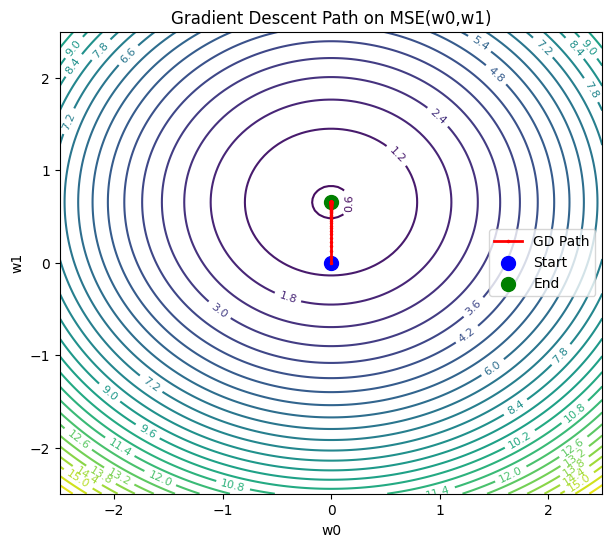

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# grid over w0, w1 for contour
w0_min, w0_max = -2.5, 2.5
w1_min, w1_max = -2.5, 2.5
W0, W1 = np.meshgrid(np.linspace(w0_min, w0_max, 120),
                     np.linspace(w1_min, w1_max, 120))

J = np.zeros_like(W0)
for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        w = np.array([[W0[i,j]],[W1[i,j]]])
        J[i,j] = mse_cost(w)

plt.figure(figsize=(7,6))
CS = plt.contour(W0, W1, J, levels=30)
plt.clabel(CS, inline=1, fontsize=8)

# convert traj into shape (steps,2) for easy plotting
traj_2d = traj.reshape(traj.shape[0], traj.shape[1])

# overlay GD path (in red)
plt.plot(traj_2d[:,0], traj_2d[:,1], 'r.-', linewidth=2, markersize=3, label="GD Path")

# mark start and end points
plt.scatter(traj_2d[0,0], traj_2d[0,1], c='blue', s=100, label='Start')
plt.scatter(traj_2d[-1,0], traj_2d[-1,1], c='green', s=100, label='End')

plt.title("Gradient Descent Path on MSE(w0,w1)")
plt.xlabel("w0")
plt.ylabel("w1")
plt.legend()
plt.show()



**Fit check: predicted vs actual + line**

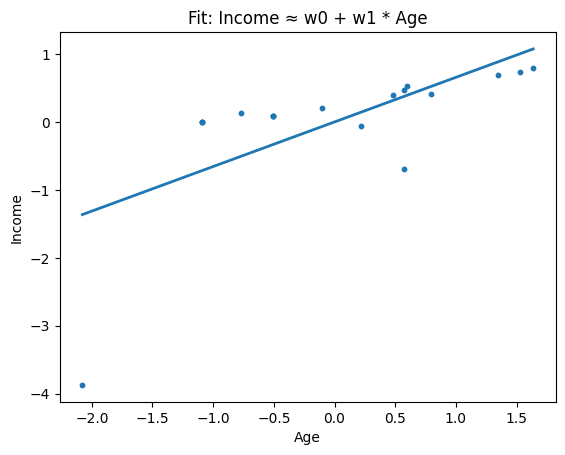

In [8]:
# Show the regression line on (x,y) scatter to verify fit
y_hat = w_star[0,0] + w_star[1,0] * x
plt.figure()
plt.scatter(x, y, s=10)
plt.plot(np.sort(x, axis=0), y_hat[np.argsort(x, axis=0).ravel()], linewidth=2)
plt.title(f"Fit: {y_col} ≈ w0 + w1 * {x_col}")
plt.xlabel(x_col); plt.ylabel(y_col)
plt.show()


**What Each Variable Means:**

- **w₀ (intercept):** Income when Age = 0 (baseline income)
- **w₁ (slope):** How much Income increases per year of Age
- **α (learning rate):** How big steps to take (too big = overshoot, too small = slow)
- **MSE:** Average squared prediction error (lower = better fit)